In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [23]:
#시뮬레이션 함수 정의
def simulate_gbm(s_0, mu, sigma, n_sims, T, N, random_seed=42):

    np.random.seed(random_seed)
    
    dt = T/N
    dW = np.random.normal(scale = np.sqrt(dt), size=(n_sims, N))
    W = np.cumsum(dW, axis=1)
    
    time_step = np.linspace(dt, T, N)
    time_steps = np.broadcast_to(time_step, (n_sims, N))
    
    S_t = s_0 * np.exp((mu - 0.5 * sigma**2) * time_steps 
                       + sigma * W)
    S_t = np.insert(S_t, 0, s_0, axis=1)
    
    return S_t

### 데이터 불러오기(마이크로소프트 2019년 1~7월)

In [24]:
FILE_PATH = "../Data-collection/dailyStock"
RISKY_ASSET = 'MSFT'
START_DATE = '2019-01-01'
END_DATE = '2019-07-31'

In [25]:
msft_df = pd.read_csv(f"{FILE_PATH}/{RISKY_ASSET}.csv", encoding="utf-8")
msft_df['Date'] = pd.to_datetime(msft_df['Date']) # 날짜로 변환
msft_df = msft_df.set_index('Date')               # Date를 인덱스로 설정
msft_df = msft_df.loc[START_DATE:END_DATE]        # 분석 기간

평균수익률: 0.22%


<Axes: title={'center': '마이크로소프트 단순수익률 2019-01-01~2019-07-31'}, xlabel='Date'>

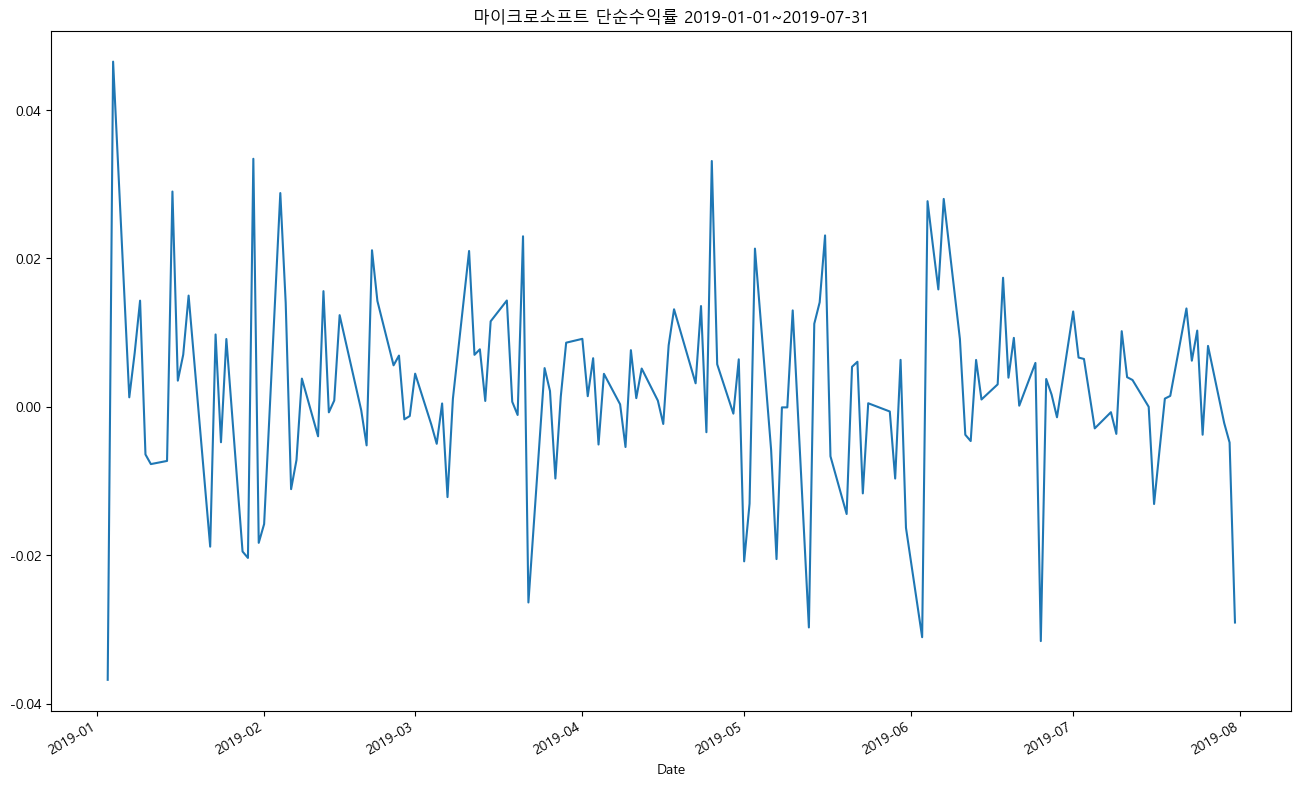

In [26]:
returns = msft_df["adj_close"].pct_change().dropna()
print(f'평균수익률: {100 * returns.mean():.2f}%')
returns.plot(title=f"마이크로소프트 단순수익률 {START_DATE}~{END_DATE}", figsize=(16,10))

### 훈련데이터와 테스트데이터 분할

In [27]:
train = returns['2019-01-01':'2019-06-30']
test = returns['2019-07-01':'2019-07-31']

### 시뮬레이션 매개변수 설정

In [28]:
T = len(test)
N = len(test)
S_0 = msft_df["adj_close"][train.index[-1]]
N_SIM = 100
mu = train.mean()
sigma = train.std()

In [29]:
gbm_simulations = simulate_gbm(S_0, mu, sigma, N_SIM, T, N)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20068\3565529694.py:13: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  line_1, = ax.plot(index, gbm_simulations_df.mean(axis=1),


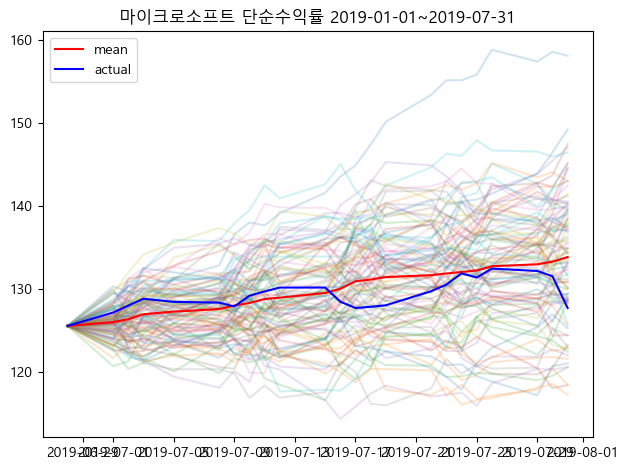

In [32]:
last_train_date = train.index[-1].date()
first_test_date = test.index[0].date()
last_test_date = test.index[-1].date()
plot_title = f"마이크로소프트 단순수익률 {START_DATE}~{END_DATE}"

selected_indices = msft_df["adj_close"][last_train_date:last_test_date].index
index = [date.date() for date in selected_indices]

gbm_simulations_df = pd.DataFrame(np.transpose(gbm_simulations), 
                                  index=index)

ax = gbm_simulations_df.plot(alpha=0.2, legend=False)
line_1, = ax.plot(index, gbm_simulations_df.mean(axis=1), 
                  color='red')
line_2, = ax.plot(index, msft_df["adj_close"][last_train_date:last_test_date], 
                  color='blue')

ax.set_title(plot_title)
ax.legend((line_1, line_2), ('mean', 'actual'))

plt.tight_layout()
plt.show()